# Credit Card Fraud Detection - IEEE-CIS Dataset
Pipeline (7 classifiers, K-based feature selection, SMOTE)

# Import Libraries

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
sns.set(font_scale=1)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Load Dataset
Using transaction data only (per supervisor instruction) — identity file is not merged.

In [9]:
TRAIN_PATH = "/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_transaction.csv"

df = pd.read_csv(TRAIN_PATH)

print("Shape:", df.shape)
df.head()

Shape: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Dataset Overview

In [10]:
print("="*50)
print("DATASET INFO")
print("="*50)
df.info()

print("="*50)
print("MISSING VALUES (top 20)")
print("="*50)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing.head(20))

print("="*50)
print("DUPLICATES")
print("="*50)
print("Duplicate rows:", df.duplicated().sum())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB
MISSING VALUES (top 20)


dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D8       515614
D9       515614
V156     508595
V139     508595
V138     508595
V141     508595
V146     508595
V147     508595
V142     508595
V149     508595
V140     508595
V153     508595
V154     508595
V158     508595
dtype: int64

DUPLICATES
Duplicate rows: 0


## Target Class Distribution

isFraud
0    569877
1     20663
Name: count, dtype: int64

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


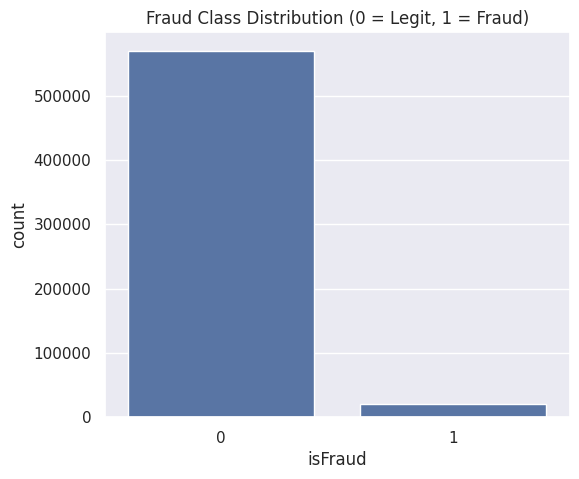

In [11]:
print(df["isFraud"].value_counts())
print()
print(df["isFraud"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,5))
sns.countplot(x="isFraud", data=df)
plt.title("Fraud Class Distribution (0 = Legit, 1 = Fraud)")
plt.show()

# Preprocessing

## Separate Target

In [12]:
y = df["isFraud"].copy()
X_raw = df.drop(columns=["isFraud"]).copy()

print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)

X_raw shape: (590540, 393)
y shape: (590540,)


## Drop Columns With >90% Missing Values

In [13]:
threshold = 90

missing_pct = (X_raw.isnull().sum() / len(X_raw)) * 100
drop_cols = missing_pct[missing_pct > threshold].index.tolist()

print("Columns to drop (>90% missing):", len(drop_cols))

X_raw.drop(columns=drop_cols, inplace=True)

print("New shape:", X_raw.shape)

Columns to drop (>90% missing): 2
New shape: (590540, 391)


## Duplicate Check

In [14]:
dupes = X_raw.duplicated().sum()
print("Duplicate rows:", dupes)

# NOTE: we do NOT drop duplicate rows here from X_raw alone, since
# y must stay aligned with X_raw row-for-row. If duplicates need
# removing, drop on the combined frame (X_raw + y) together, e.g.:
combo = pd.concat([X_raw, y], axis=1)
combo.drop_duplicates(inplace=True)
X_raw = combo.drop(columns=["isFraud"])
y = combo["isFraud"]

print("Shape after dedup:", X_raw.shape, y.shape)

Duplicate rows: 0
Shape after dedup: (590540, 391) (590540,)


## Missing Value Imputation

In [15]:
num_cols = X_raw.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_raw.select_dtypes(include=["object"]).columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

for col in num_cols:
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())

for col in cat_cols:
    X_raw[col] = X_raw[col].fillna("Unknown")

print("Remaining missing values:", X_raw.isnull().sum().sum())

Numerical columns: 377
Categorical columns: 14
Remaining missing values: 0


## Label Encoding

In [16]:
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_raw[col] = le.fit_transform(X_raw[col].astype(str))
    label_encoders[col] = le

print("Encoding completed. Final feature count:", X_raw.shape[1])

Encoding completed. Final feature count: 391


## Preprocessing Sanity Check

In [10]:
# Verify preprocessing integrity
print("Raw dataset:", df.shape)
print("After separating target:", X_check.shape if 'X_check' in dir() else X_raw.shape)
print("Columns dropped (>90% missing):", 394 - 1 - X_raw.shape[1], "->", ['dist2', 'D7'])
print("Final feature count:", X_raw.shape[1])
print("Categorical columns encoded:", len(cat_cols))
print(cat_cols.tolist())

Raw dataset: (590540, 394)
After separating target: (590540, 391)
Columns dropped (>90% missing): 2 -> ['dist2', 'D7']
Final feature count: 391
Categorical columns encoded: 14
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


## Train / Validation Split
Split BEFORE scaling/selection/SMOTE to avoid data leakage.

In [17]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_raw, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

Train: (472432, 391)
Valid: (118108, 391)


## Feature Scaling

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

## K-Based Feature Selection (Top 50)
SelectKBest with mutual information — reduces 394 -> 50 features, fit on TRAIN only.

In [19]:
K = 50

selector = SelectKBest(score_func=mutual_info_classif, k=K)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_valid_selected = selector.transform(X_valid_scaled)

selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()

print("Selected feature count:", X_train_selected.shape[1])
print("Selected features:", selected_features)

Selected feature count: 50
Selected features: ['ProductCD', 'card3', 'card6', 'M1', 'M2', 'M4', 'M6', 'M7', 'V10', 'V11', 'V12', 'V13', 'V15', 'V16', 'V17', 'V18', 'V21', 'V22', 'V29', 'V30', 'V31', 'V33', 'V34', 'V35', 'V36', 'V39', 'V40', 'V42', 'V43', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V58', 'V69', 'V70', 'V75', 'V76', 'V79', 'V80', 'V90', 'V91', 'V92', 'V93', 'V94', 'V302', 'V304']


## SMOTE (applied to TRAINING data only, AFTER feature selection)

In [20]:
smote = SMOTE(random_state=42)

X_train_final, y_train_final = smote.fit_resample(X_train_selected, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print()
print("After SMOTE:")
print(y_train_final.value_counts())

Before SMOTE:
isFraud
0    455902
1     16530
Name: count, dtype: int64

After SMOTE:
isFraud
0    455902
1    455902
Name: count, dtype: int64


# EDA
Note: EDA plots use the pre-selection feature set (X_train / X_raw) so raw column names like TransactionAmt are still available.

## Histogram

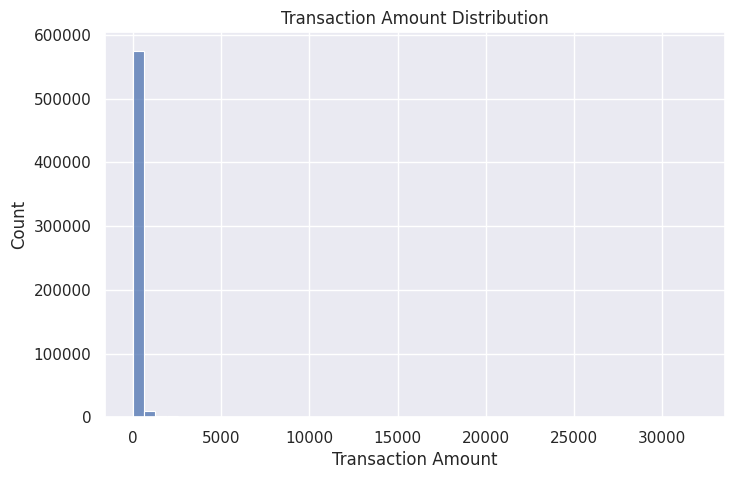

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(X_raw["TransactionAmt"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.show()

## Boxplot

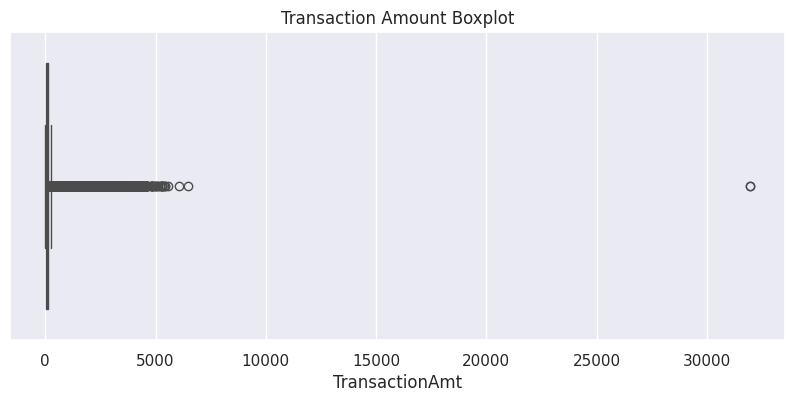

In [16]:
plt.figure(figsize=(10,4))
sns.boxplot(x=X_raw["TransactionAmt"])
plt.title("Transaction Amount Boxplot")
plt.show()

## Correlation Heatmap (Top 20 features correlated with TransactionAmt)

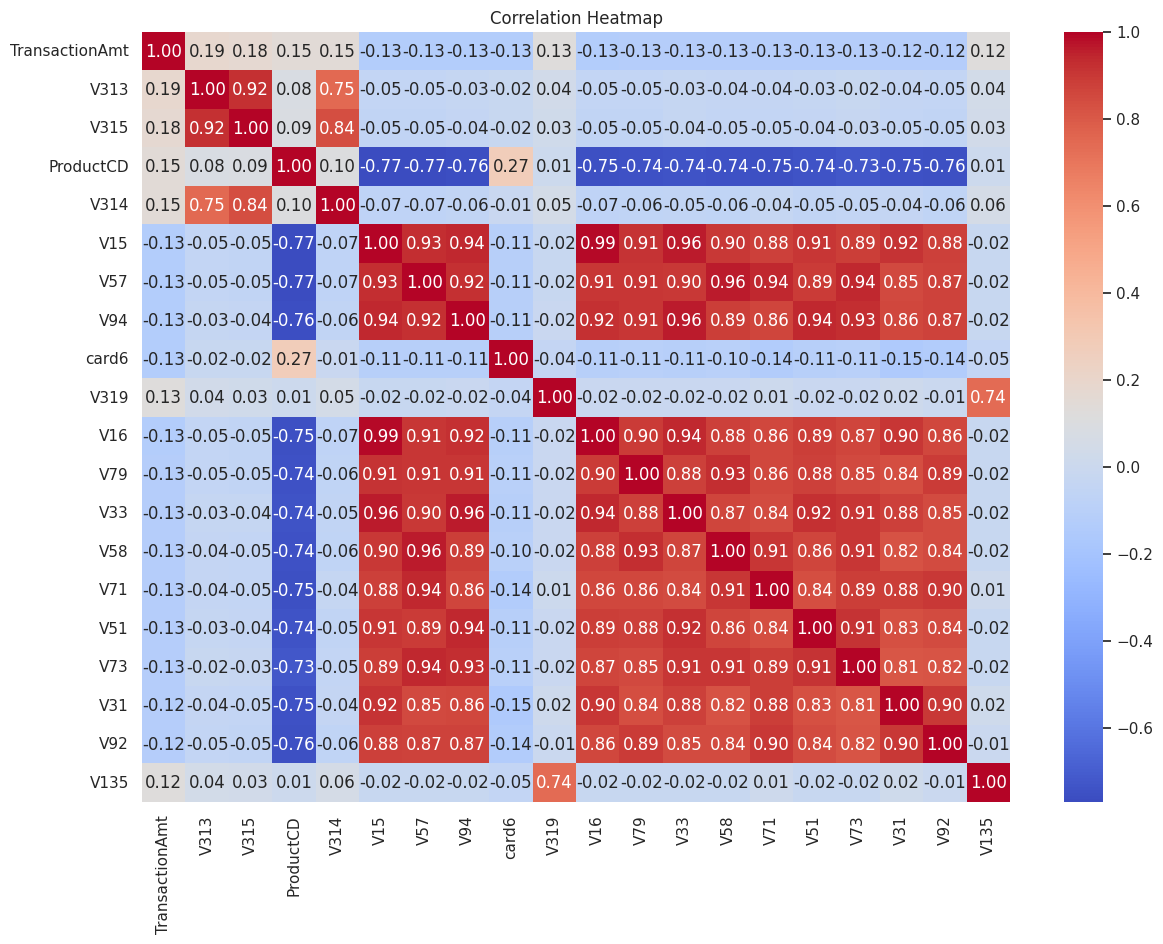

In [17]:
top_corr = X_raw.corr(numeric_only=True)["TransactionAmt"].abs().sort_values(ascending=False).head(20).index

plt.figure(figsize=(14,10))
sns.heatmap(X_raw[top_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Scatter Plot

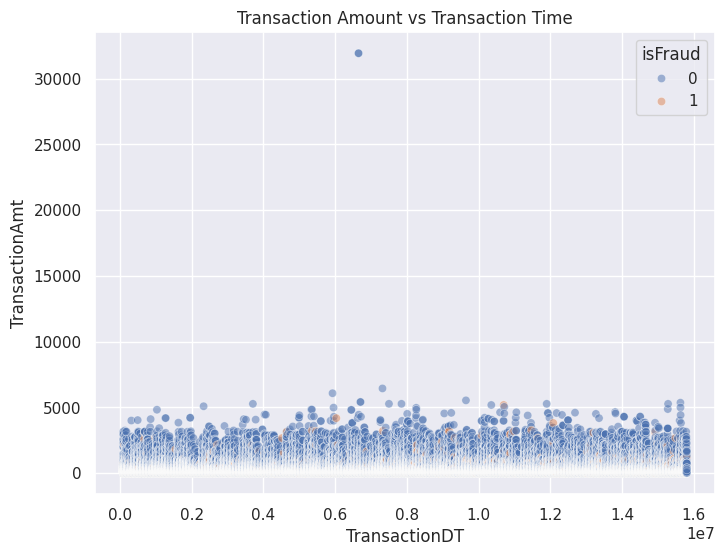

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_raw["TransactionDT"], y=X_raw["TransactionAmt"], hue=y, alpha=0.5)
plt.title("Transaction Amount vs Transaction Time")
plt.show()

## Pair Plot

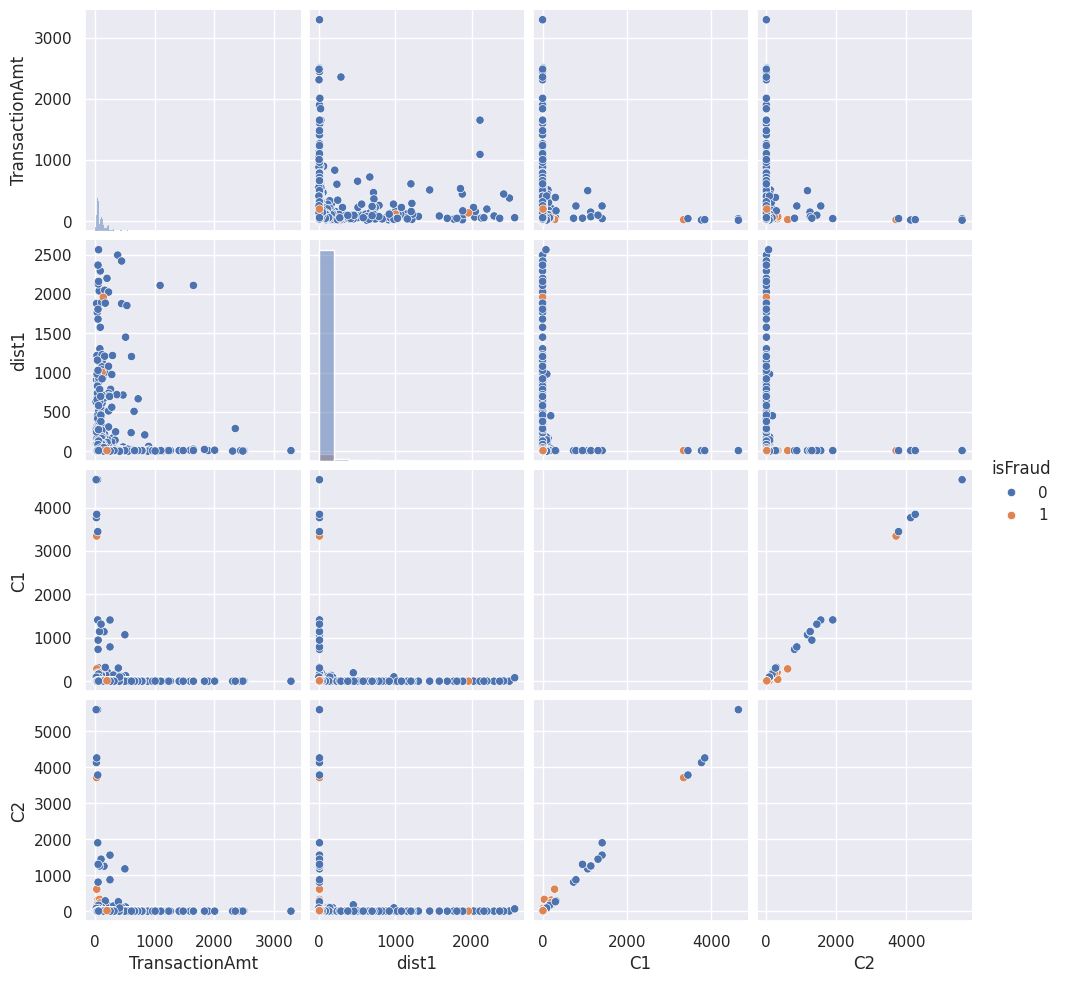

In [19]:
pair_columns = ["TransactionAmt", "dist1", "C1", "C2"]
pair_df = X_raw[pair_columns].copy()
pair_df["isFraud"] = y.values

sns.pairplot(pair_df.sample(min(3000, len(pair_df)), random_state=42), hue="isFraud", diag_kind="hist")
plt.show()

# Evaluation Function

In [22]:
from sklearn.metrics import precision_recall_curve

def evaluate_model(model, X_eval, y_eval, name=""):
    prob = model.predict_proba(X_eval)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_eval, prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = f1_scores.argmax()
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

    pred = (prob >= best_threshold).astype(int)

    metrics = {
        "Model": name,
        "Threshold": best_threshold,
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred),
        "Recall": recall_score(y_eval, pred),
        "F1 Score": f1_score(y_eval, pred),
        "ROC AUC": roc_auc_score(y_eval, prob)
    }

    print("="*50)
    print(f"{name} Performance (Threshold={best_threshold:.3f})")
    print("="*50)
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {round(v, 4)}")
    print()
    print(classification_report(y_eval, pred))

    cm = confusion_matrix(y_eval, pred, normalize='true')

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues")
    plt.title(f"{name} — Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, _ = roc_curve(y_eval, prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0,1], [0,1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} — ROC Curve")
    plt.legend()
    plt.show()

    return metrics

all_results = []

# Logistic Regression

Logistic Regression Performance (Threshold=0.746)
Threshold: 0.7456
Accuracy: 0.9357
Precision: 0.2103
Recall: 0.3034
F1 Score: 0.2484
ROC AUC: 0.7813

              precision    recall  f1-score   support

           0       0.97      0.96      0.97    113975
           1       0.21      0.30      0.25      4133

    accuracy                           0.94    118108
   macro avg       0.59      0.63      0.61    118108
weighted avg       0.95      0.94      0.94    118108



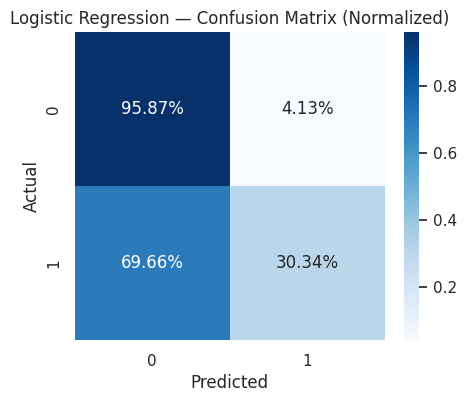

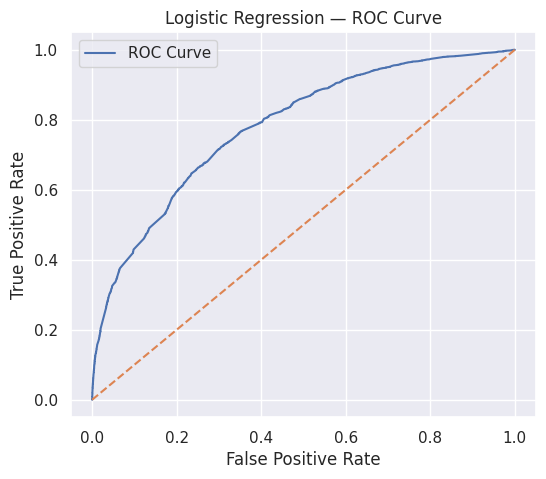

In [21]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_final, y_train_final)

all_results.append(evaluate_model(lr, X_valid_selected, y_valid, "Logistic Regression"))

# Decision Tree

Decision Tree Performance (Threshold=0.806)
Threshold: 0.8058
Accuracy: 0.9404
Precision: 0.2455
Recall: 0.3387
F1 Score: 0.2847
ROC AUC: 0.7916

              precision    recall  f1-score   support

           0       0.98      0.96      0.97    113975
           1       0.25      0.34      0.28      4133

    accuracy                           0.94    118108
   macro avg       0.61      0.65      0.63    118108
weighted avg       0.95      0.94      0.94    118108



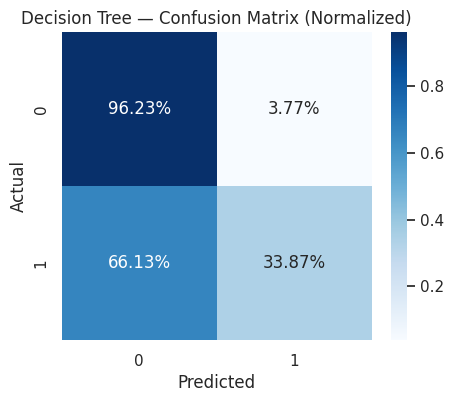

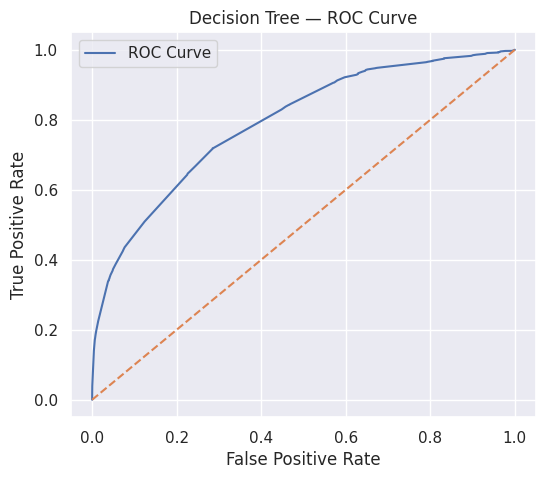

In [22]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_final, y_train_final)

all_results.append(evaluate_model(dt, X_valid_selected, y_valid, "Decision Tree"))

# Random Forest

Random Forest Performance (Threshold=0.744)
Threshold: 0.7439
Accuracy: 0.9465
Precision: 0.2788
Recall: 0.3334
F1 Score: 0.3037
ROC AUC: 0.8218

              precision    recall  f1-score   support

           0       0.98      0.97      0.97    113975
           1       0.28      0.33      0.30      4133

    accuracy                           0.95    118108
   macro avg       0.63      0.65      0.64    118108
weighted avg       0.95      0.95      0.95    118108



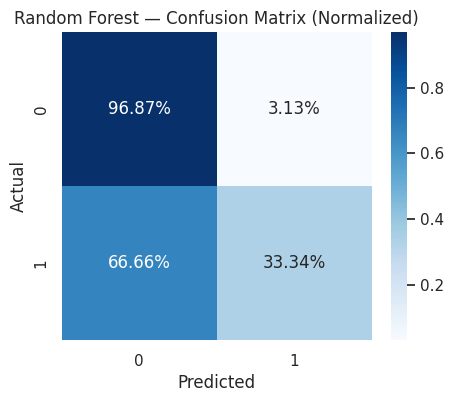

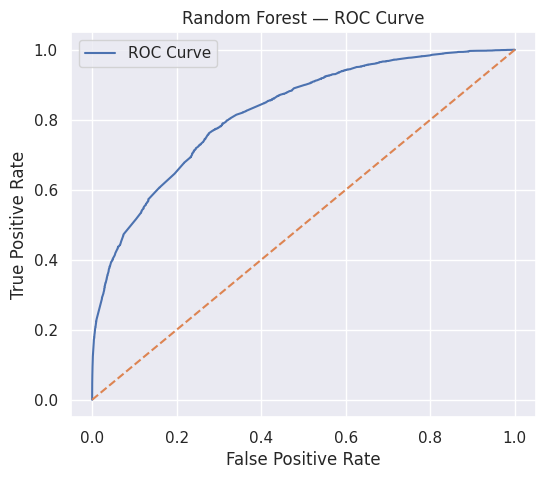

In [23]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_final, y_train_final)

all_results.append(evaluate_model(rf, X_valid_selected, y_valid, "Random Forest"))

# SVM
Note: SVC on ~470K resampled rows is slow. Using a linear kernel + probability=True keeps it tractable; consider subsampling X_train_final further if runtime is an issue on Kaggle's free tier.

SVM training rows: 40000
SVM Performance (Threshold=0.736)
Threshold: 0.7362
Accuracy: 0.9356
Precision: 0.2067
Recall: 0.2966
F1 Score: 0.2437
ROC AUC: 0.77

              precision    recall  f1-score   support

           0       0.97      0.96      0.97    113975
           1       0.21      0.30      0.24      4133

    accuracy                           0.94    118108
   macro avg       0.59      0.63      0.61    118108
weighted avg       0.95      0.94      0.94    118108



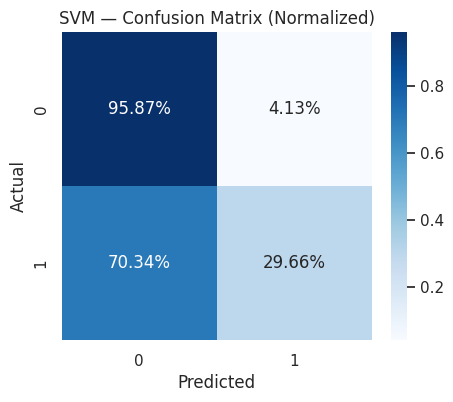

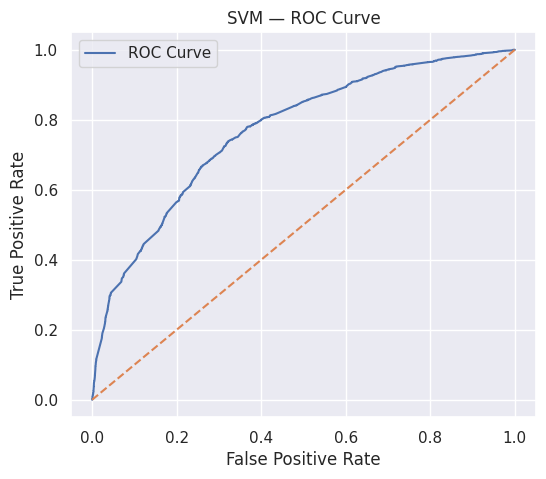

In [24]:
from sklearn.model_selection import train_test_split as _tts

SVM_SAMPLE_SIZE = 40000

if len(X_train_final) > SVM_SAMPLE_SIZE:
    X_train_svm, _, y_train_svm, _ = _tts(
        X_train_final, y_train_final,
        train_size=SVM_SAMPLE_SIZE,
        stratify=y_train_final,
        random_state=42
    )
else:
    X_train_svm, y_train_svm = X_train_final, y_train_final

print("SVM training rows:", len(X_train_svm))

svm = SVC(kernel="linear", probability=True, random_state=42)
svm.fit(X_train_svm, y_train_svm)

all_results.append(evaluate_model(svm, X_valid_selected, y_valid, "SVM"))

# KNN

KNN Performance (Threshold=0.600)
Threshold: 0.6
Accuracy: 0.9631
Precision: 0.4517
Recall: 0.2536
F1 Score: 0.3248
ROC AUC: 0.6861

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    113975
           1       0.45      0.25      0.32      4133

    accuracy                           0.96    118108
   macro avg       0.71      0.62      0.65    118108
weighted avg       0.96      0.96      0.96    118108



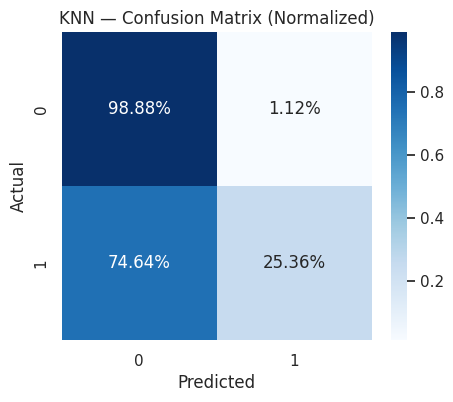

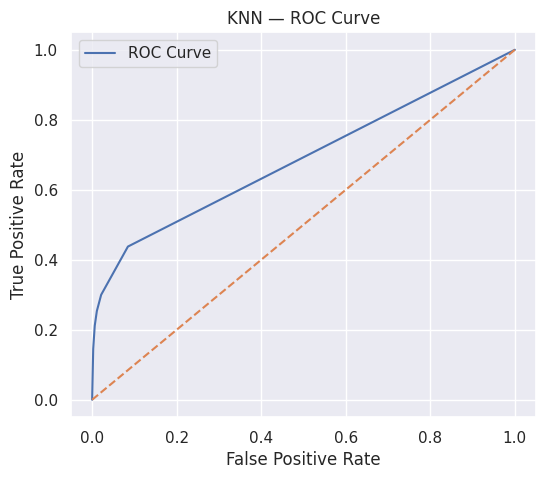

In [25]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_final, y_train_final)

all_results.append(evaluate_model(knn, X_valid_selected, y_valid, "KNN"))

# Naive Bayes

Naive Bayes Performance (Threshold=1.000)
Threshold: 1.0
Accuracy: 0.8801
Precision: 0.1167
Recall: 0.3692
F1 Score: 0.1773
ROC AUC: 0.7446

              precision    recall  f1-score   support

           0       0.98      0.90      0.94    113975
           1       0.12      0.37      0.18      4133

    accuracy                           0.88    118108
   macro avg       0.55      0.63      0.56    118108
weighted avg       0.95      0.88      0.91    118108



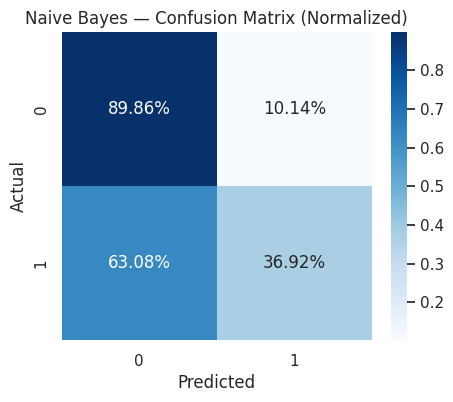

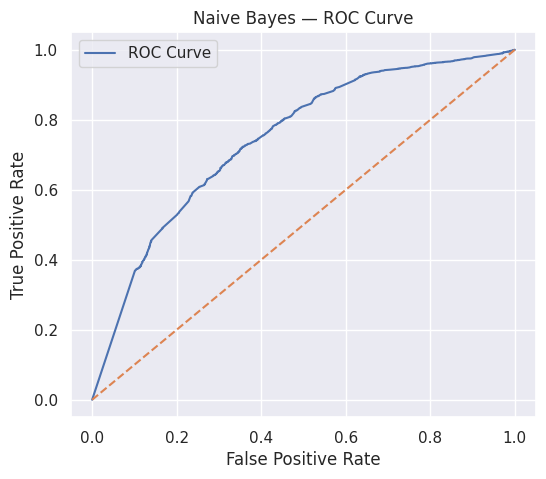

In [26]:
nb = GaussianNB()
nb.fit(X_train_final, y_train_final)

all_results.append(evaluate_model(nb, X_valid_selected, y_valid, "Naive Bayes"))

# XGBoost

XGBoost Performance (Threshold=0.745)
Threshold: 0.7455000281333923
Accuracy: 0.9454
Precision: 0.2742
Recall: 0.3397
F1 Score: 0.3035
ROC AUC: 0.8197

              precision    recall  f1-score   support

           0       0.98      0.97      0.97    113975
           1       0.27      0.34      0.30      4133

    accuracy                           0.95    118108
   macro avg       0.63      0.65      0.64    118108
weighted avg       0.95      0.95      0.95    118108



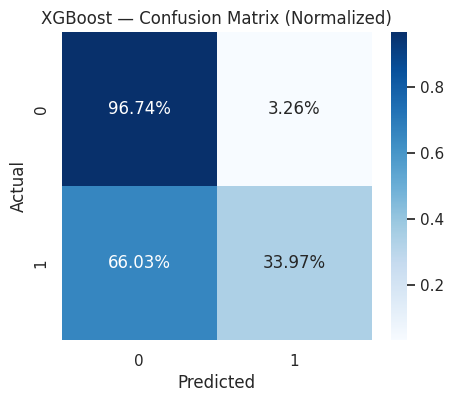

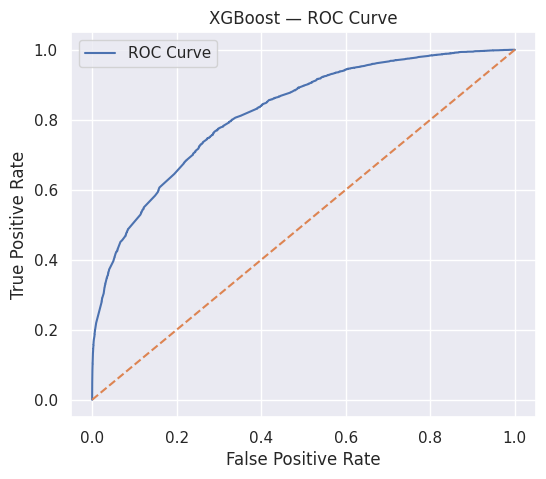

In [27]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train_final, y_train_final)

all_results.append(evaluate_model(xgb, X_valid_selected, y_valid, "XGBoost"))

# Model Comparison Table

In [28]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.693586,0.943094,0.267350,0.359787,0.306756,0.822550
1,XGBoost,0.745470,0.945431,0.274219,0.339705,0.303469,0.819681
2,Decision Tree,0.805755,0.940436,0.245528,0.338737,0.284698,0.791591
3,Logistic Regression,0.745630,0.935745,0.210262,0.303412,0.248391,0.781322
4,SVM,0.736197,0.935559,0.206745,0.296637,0.243665,0.770008
5,Naive Bayes,1.000000,0.880118,0.116685,0.369223,0.177328,0.744640
6,KNN,0.600000,0.963110,0.451724,0.253569,0.324810,0.686147


# Best Model

In [29]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model Selected:", best_model_name)

Best Model Selected: Random Forest


# Stability check

In [30]:
#Does Random Forest reliably beat XGBoost, or is it close-call noise?
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

seed_results = []

for seed in [0, 1, 42, 123, 999]:
    rf_s = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=seed, n_jobs=-1)
    rf_s.fit(X_train_final, y_train_final)
    rf_auc = roc_auc_score(y_valid, rf_s.predict_proba(X_valid_selected)[:, 1])

    xgb_s = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=seed
    )
    xgb_s.fit(X_train_final, y_train_final)
    xgb_auc = roc_auc_score(y_valid, xgb_s.predict_proba(X_valid_selected)[:, 1])

    seed_results.append({"Seed": seed, "RF ROC-AUC": rf_auc, "XGBoost ROC-AUC": xgb_auc})

seed_df = pd.DataFrame(seed_results)
seed_df["Winner"] = seed_df.apply(lambda r: "RF" if r["RF ROC-AUC"] > r["XGBoost ROC-AUC"] else "XGBoost", axis=1)
display(seed_df)
print("\nAverage RF ROC-AUC:", seed_df["RF ROC-AUC"].mean())
print("Average XGBoost ROC-AUC:", seed_df["XGBoost ROC-AUC"].mean())

,Seed,RF ROC-AUC,XGBoost ROC-AUC,Winner
0,0,0.822670,0.819100,RF
1,1,0.822591,0.819282,RF
2,42,0.822550,0.819681,RF
3,123,0.821980,0.818474,RF
4,999,0.822236,0.819123,RF



Average RF ROC-AUC: 0.8224053958883146
Average XGBoost ROC-AUC: 0.8191319728906382


# Ablation Table


Running ablation for K = 30
K=30 done. ROC AUC: 0.8070

Running ablation for K = 50
K=50 done. ROC AUC: 0.8227

Running ablation for K = 60
K=60 done. ROC AUC: 0.8272

Running ablation for K = 70
K=70 done. ROC AUC: 0.8467

Running ablation for K = 80
K=80 done. ROC AUC: 0.8704


,K (Feature Count),Accuracy,Precision,Recall,F1 Score,ROC AUC
0,30,0.726682,0.088022,0.727559,0.157044,0.806988
1,50,0.754953,0.096510,0.717880,0.170146,0.822696
2,60,0.768661,0.101108,0.711106,0.177043,0.827220
3,70,0.823009,0.127394,0.693685,0.215256,0.846735
4,80,0.868730,0.164987,0.677474,0.265353,0.870396


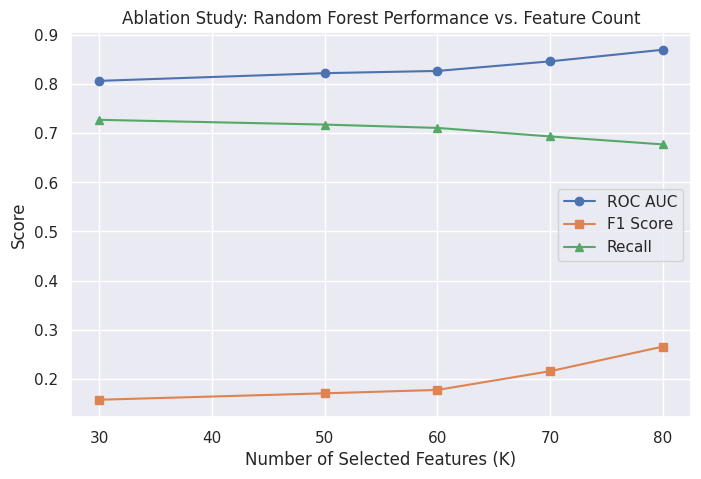

In [31]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

K_VALUES = [30, 50, 60, 70, 80]
ablation_results = []

for k in K_VALUES:
    print(f"\n{'='*50}\nRunning ablation for K = {k}\n{'='*50}")

    # Feature selection at this K
    selector_k = SelectKBest(score_func=mutual_info_classif, k=k)
    X_train_k = selector_k.fit_transform(X_train_scaled, y_train)
    X_valid_k = selector_k.transform(X_valid_scaled)

    # SMOTE on this K's training set
    smote_k = SMOTE(random_state=42)
    X_train_k_final, y_train_k_final = smote_k.fit_resample(X_train_k, y_train)

    # Train Random Forest
    rf_k = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    rf_k.fit(X_train_k_final, y_train_k_final)

    # Evaluate
    pred_k = rf_k.predict(X_valid_k)
    prob_k = rf_k.predict_proba(X_valid_k)[:, 1]

    ablation_results.append({
        "K (Feature Count)": k,
        "Accuracy": accuracy_score(y_valid, pred_k),
        "Precision": precision_score(y_valid, pred_k),
        "Recall": recall_score(y_valid, pred_k),
        "F1 Score": f1_score(y_valid, pred_k),
        "ROC AUC": roc_auc_score(y_valid, prob_k)
    })

    print(f"K={k} done. ROC AUC: {ablation_results[-1]['ROC AUC']:.4f}")

ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.sort_values(by="K (Feature Count)").reset_index(drop=True)
display(ablation_df)

plt.figure(figsize=(8,5))
plt.plot(ablation_df["K (Feature Count)"], ablation_df["ROC AUC"], marker='o', label="ROC AUC")
plt.plot(ablation_df["K (Feature Count)"], ablation_df["F1 Score"], marker='s', label="F1 Score")
plt.plot(ablation_df["K (Feature Count)"], ablation_df["Recall"], marker='^', label="Recall")
plt.xlabel("Number of Selected Features (K)")
plt.ylabel("Score")
plt.title("Ablation Study: Random Forest Performance vs. Feature Count")
plt.legend()
plt.grid(True)
plt.show()

## Hyperparameter Tuning with K-Fold Cross-Validation

In [32]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Random Forest tuning ---
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'class_weight': ['balanced', None]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=1
)
rf_grid.fit(X_train_final, y_train_final)
print("Best RF params:", rf_grid.best_params_)
print("Best RF CV F1:", rf_grid.best_score_)
rf_best = rf_grid.best_estimator_

# --- XGBoost tuning ---
xgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [1, 3]  # helps with imbalance
}
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train_final, y_train_final)
print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB CV F1:", xgb_grid.best_score_)
xgb_best = xgb_grid.best_estimator_

# --- Logistic Regression tuning (baseline) ---
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': ['balanced', None]
}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=1
)
lr_grid.fit(X_train_final, y_train_final)
print("Best LR params:", lr_grid.best_params_)
print("Best LR CV F1:", lr_grid.best_score_)
lr_best = lr_grid.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best RF params: {'class_weight': None, 'max_depth': 20, 'n_estimators': 200}
Best RF CV F1: 0.7957555228768032
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best XGB params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'scale_pos_weight': 1}
Best XGB CV F1: 0.7942195645692418
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LR params: {'C': 0.01, 'class_weight': 'balanced'}
Best LR CV F1: 0.6977681730046028


## Threshold Tuning


Random Forest
Best threshold: 0.759 | Precision: 0.300 | Recall: 0.331 | F1: 0.315
Confusion Matrix (normalized, tuned threshold):
[[0.97194122 0.02805878]
 [0.66876361 0.33123639]]


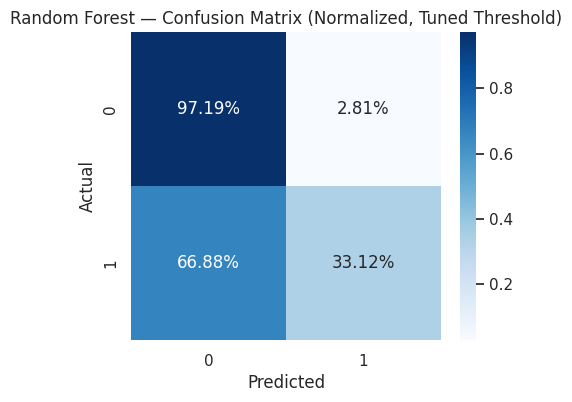


XGBoost
Best threshold: 0.754 | Precision: 0.283 | Recall: 0.338 | F1: 0.308
Confusion Matrix (normalized, tuned threshold):
[[0.96901952 0.03098048]
 [0.66198887 0.33801113]]


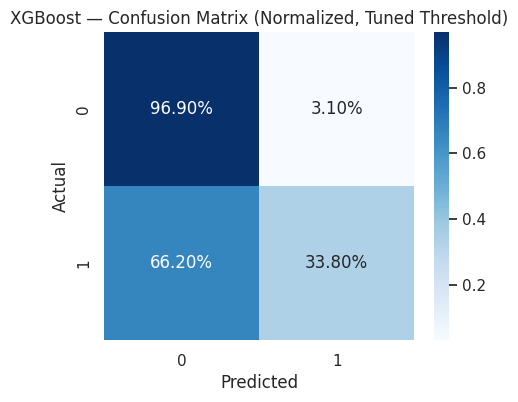


Logistic Regression
Best threshold: 0.750 | Precision: 0.212 | Recall: 0.301 | F1: 0.249
Confusion Matrix (normalized, tuned threshold):
[[0.95931564 0.04068436]
 [0.69852407 0.30147593]]


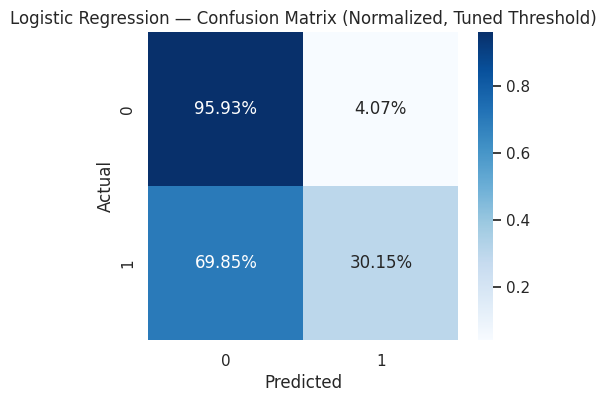

In [42]:
from sklearn.metrics import precision_recall_curve, confusion_matrix

def find_best_threshold(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y, probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = f1_scores.argmax()
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    return best_threshold, precisions[best_idx], recalls[best_idx], f1_scores[best_idx]

for name, model in [("Random Forest", rf_best), ("XGBoost", xgb_best), ("Logistic Regression", lr_best)]:
    thresh, prec, rec, f1 = find_best_threshold(model, X_valid_selected, y_valid)
    print(f"\n{name}")
    print(f"Best threshold: {thresh:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

    probs = model.predict_proba(X_valid_selected)[:, 1]
    new_preds = (probs >= thresh).astype(int)
    
    # Normalized confusion matrix (row-wise percentages)
    cm_normalized = confusion_matrix(y_valid, new_preds, normalize='true')
    print("Confusion Matrix (normalized, tuned threshold):")
    print(cm_normalized)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues")
    plt.title(f"{name} — Confusion Matrix (Normalized, Tuned Threshold)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Ensemble (Voting Classifier)

Ensemble ROC-AUC: 0.8238971875425074
Ensemble F1: 0.1774418745826504
Ensemble Recall: 0.7072344543914831
Voting Ensemble Performance (Threshold=0.683)
Threshold: 0.6826
Accuracy: 0.9418
Precision: 0.2659
Recall: 0.376
F1 Score: 0.3115
ROC AUC: 0.8239

              precision    recall  f1-score   support

           0       0.98      0.96      0.97    113975
           1       0.27      0.38      0.31      4133

    accuracy                           0.94    118108
   macro avg       0.62      0.67      0.64    118108
weighted avg       0.95      0.94      0.95    118108



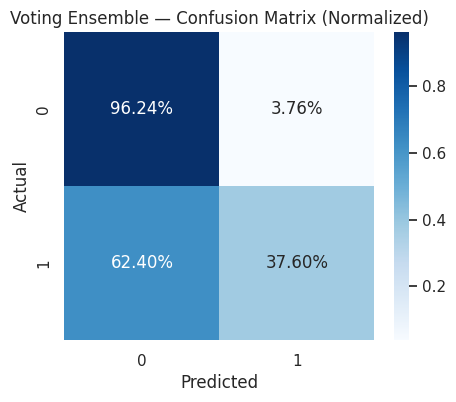

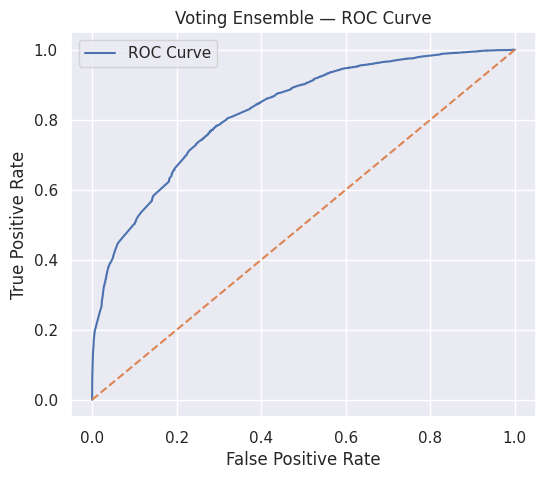

{'Model': 'Voting Ensemble',
 'Threshold': np.float64(0.6825832210317588),
 'Accuracy': 0.9418328987028821,
 'Precision': 0.26586826347305387,
 'Recall': 0.375998064360029,
 'F1 Score': 0.3114852675886951,
 'ROC AUC': np.float64(0.823897189665385)}

In [34]:
from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(
    estimators=[('rf', rf_best), ('xgb', xgb_best), ('lr', lr_best)],
    voting='soft'
)
ensemble.fit(X_train_final, y_train_final)

ens_pred = ensemble.predict(X_valid_selected)
ens_prob = ensemble.predict_proba(X_valid_selected)[:, 1]

print("Ensemble ROC-AUC:", roc_auc_score(y_valid, ens_prob))
print("Ensemble F1:", f1_score(y_valid, ens_pred))
print("Ensemble Recall:", recall_score(y_valid, ens_pred))

evaluate_model(ensemble, X_valid_selected, y_valid, "Voting Ensemble")

## Learning Curve (Train-Test Curve)

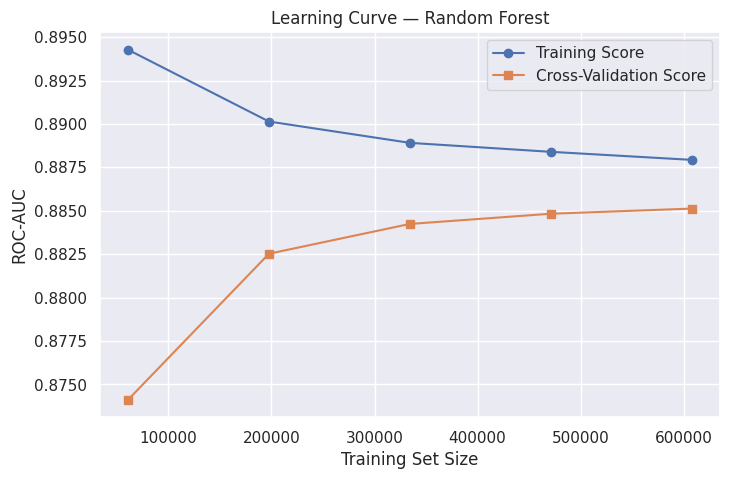

In [37]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    rf_best, X_train_final, y_train_final,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3, scoring='roc_auc', n_jobs=-1,
    shuffle=True, random_state=42
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label="Training Score")
plt.plot(train_sizes, valid_mean, 's-', label="Cross-Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve — Random Forest")
plt.legend()
plt.grid(True)
plt.show()

## Log-Loss Curve (XGBoost: built-in support)

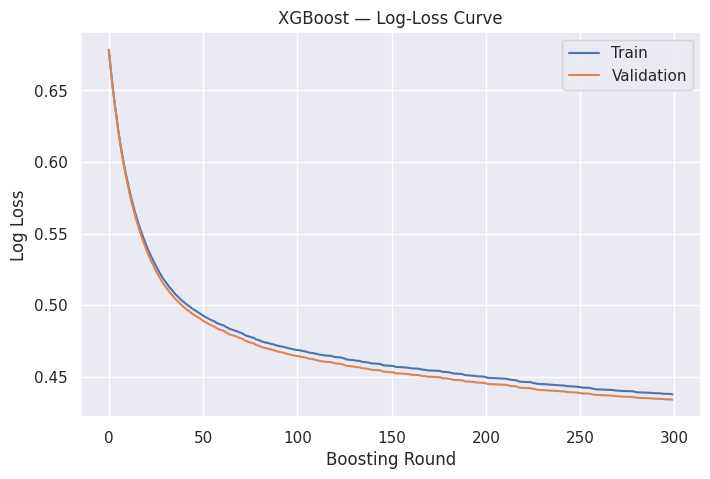

In [39]:
xgb_logloss = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    eval_metric='logloss', random_state=42
)
xgb_logloss.fit(
    X_train_final, y_train_final,
    eval_set=[(X_train_final, y_train_final), (X_valid_selected, y_valid)],
    verbose=False
)

results = xgb_logloss.evals_result()

plt.figure(figsize=(8,5))
plt.plot(results['validation_0']['logloss'], label='Train')
plt.plot(results['validation_1']['logloss'], label='Validation')
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost — Log-Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

## Final Comparison Table (Before vs After Tuning)

In [40]:
final_comparison = []
for name, model in [("Random Forest (Tuned)", rf_best), ("XGBoost (Tuned)", xgb_best),
                     ("Logistic Regression (Tuned)", lr_best), ("Voting Ensemble", ensemble)]:
    pred = model.predict(X_valid_selected)
    prob = model.predict_proba(X_valid_selected)[:, 1]
    final_comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, pred),
        "Precision": precision_score(y_valid, pred),
        "Recall": recall_score(y_valid, pred),
        "F1 Score": f1_score(y_valid, pred),
        "ROC AUC": roc_auc_score(y_valid, prob)
    })

final_df = pd.DataFrame(final_comparison).sort_values(by="ROC AUC", ascending=False)
display(final_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,Voting Ensemble,0.770549,0.101447,0.707234,0.177442,0.823897
0,Random Forest (Tuned),0.762980,0.098178,0.705299,0.172363,0.823390
1,XGBoost (Tuned),0.753946,0.095561,0.712557,0.168522,0.819691
2,Logistic Regression (Tuned),0.729129,0.083734,0.677958,0.149058,0.781293


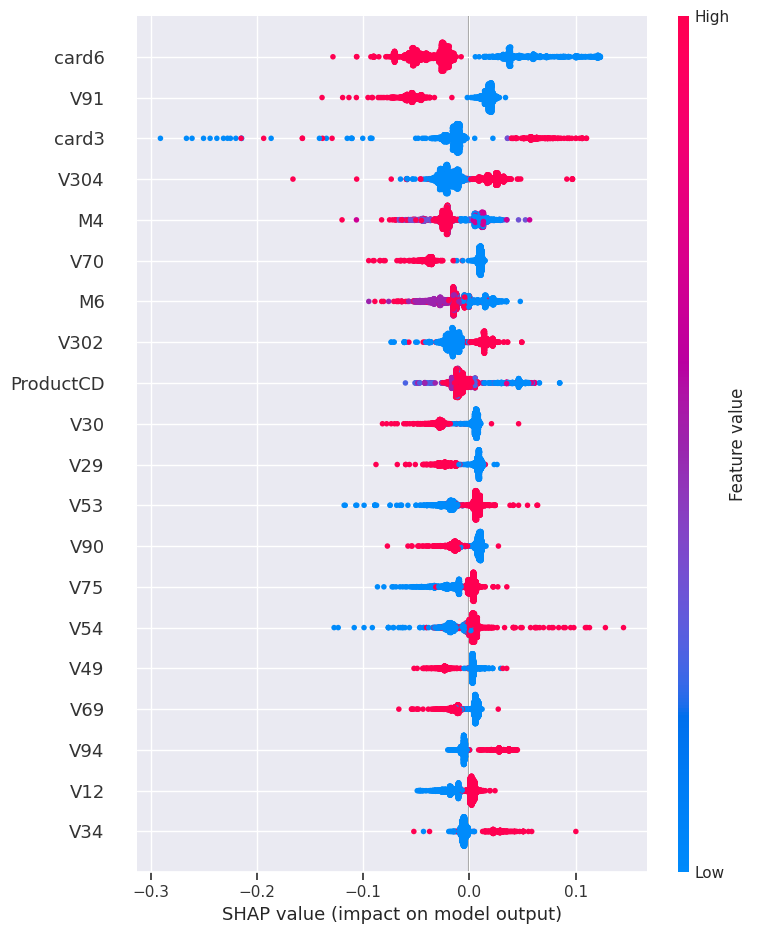

In [24]:
import shap

explainer = shap.TreeExplainer(rf)
sample = X_valid_selected[:2000]
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values[:, :, 1], sample, feature_names=selected_features)

# Diagrams

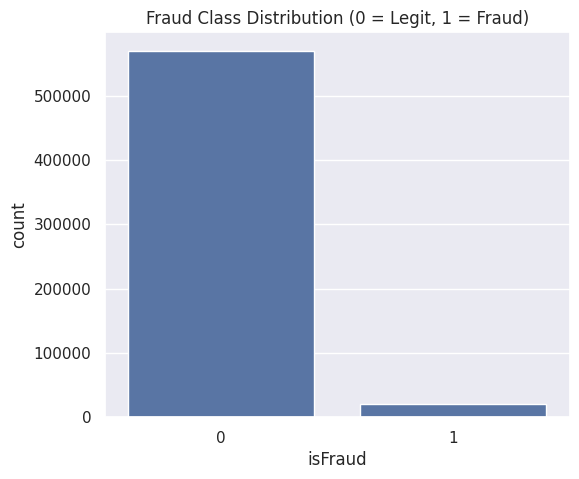

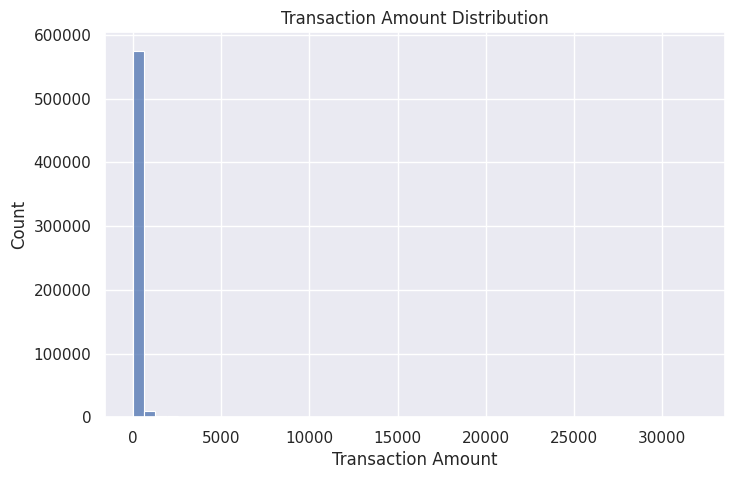

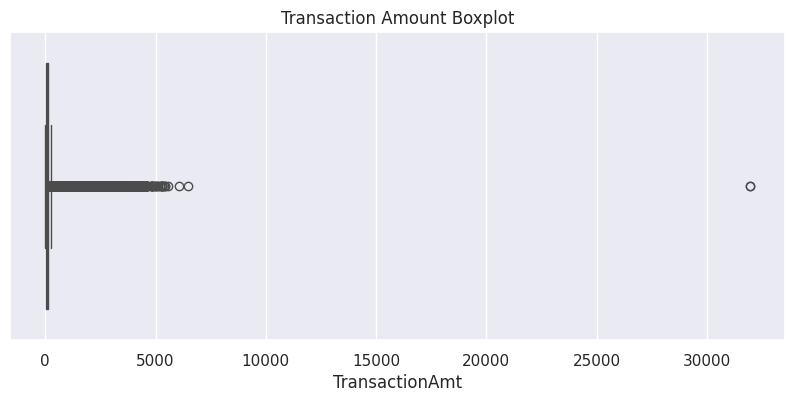

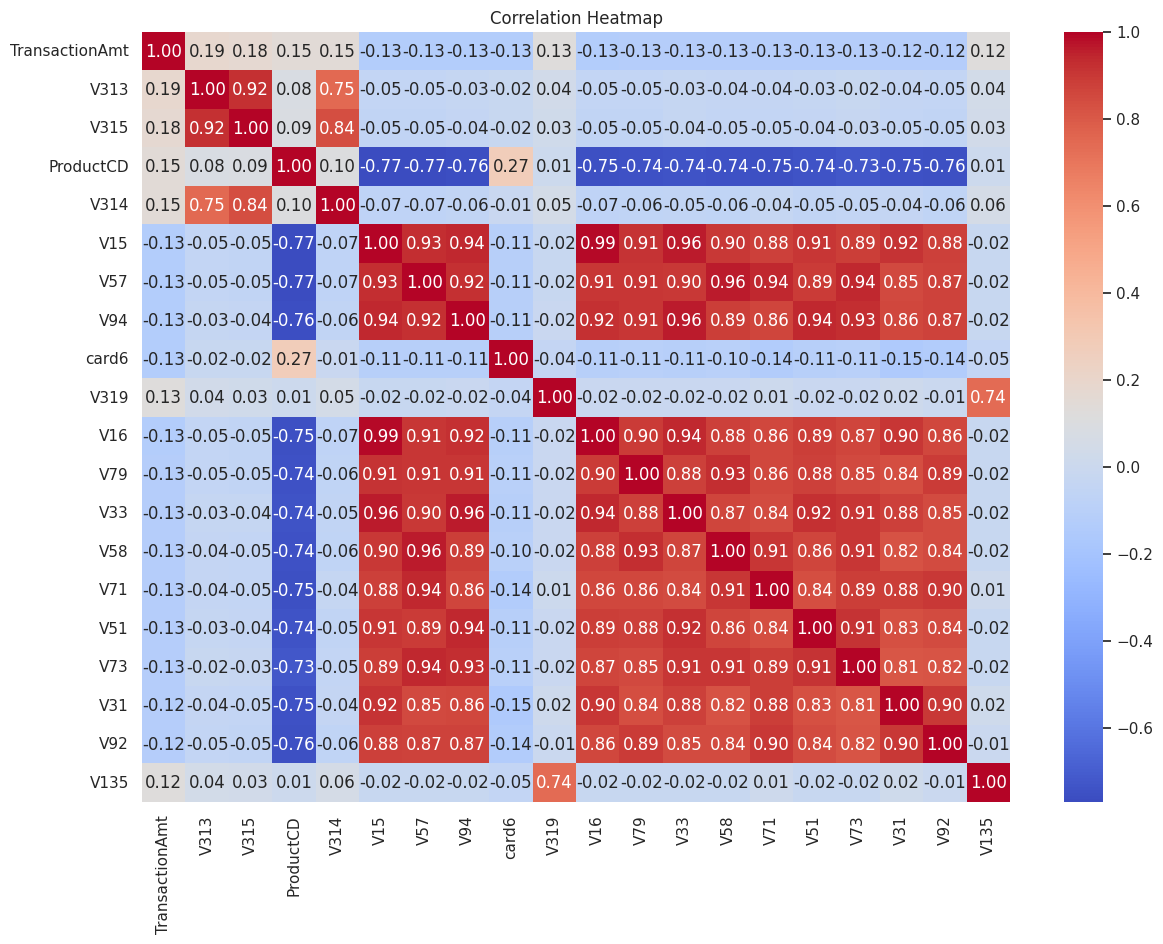

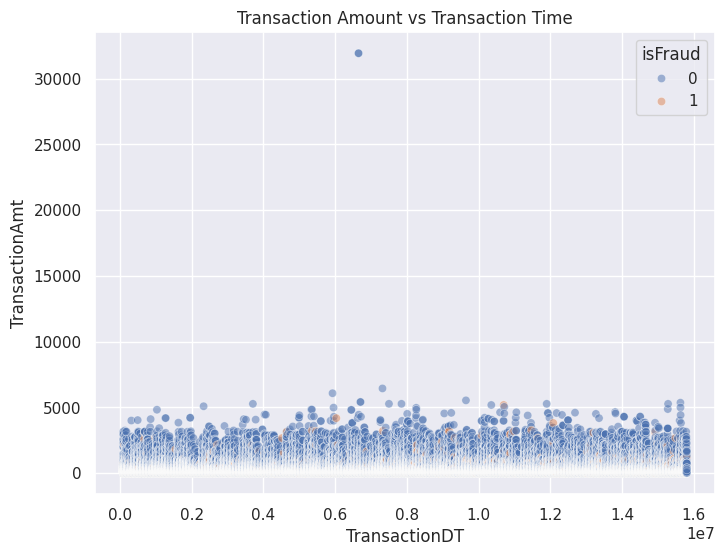

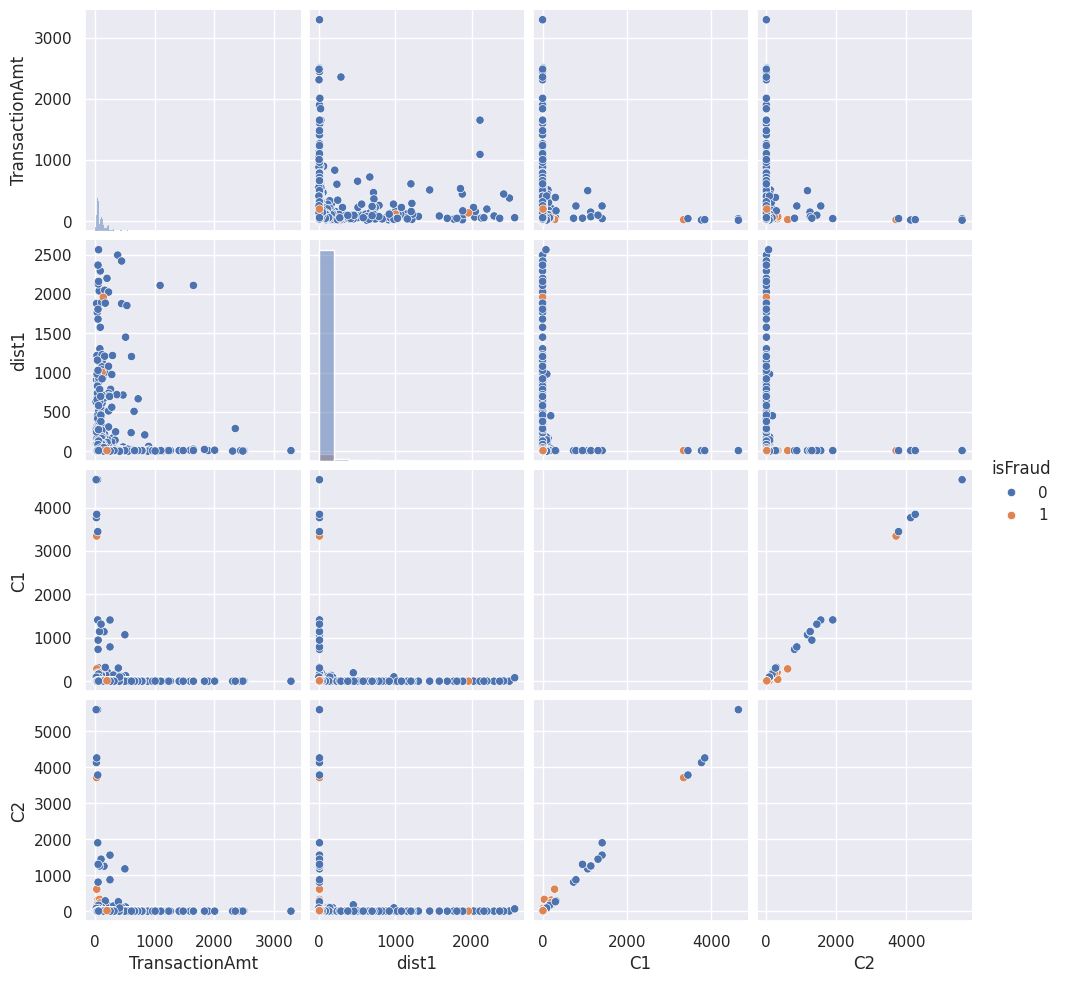

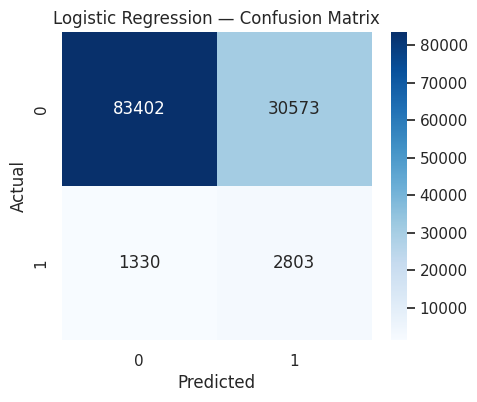

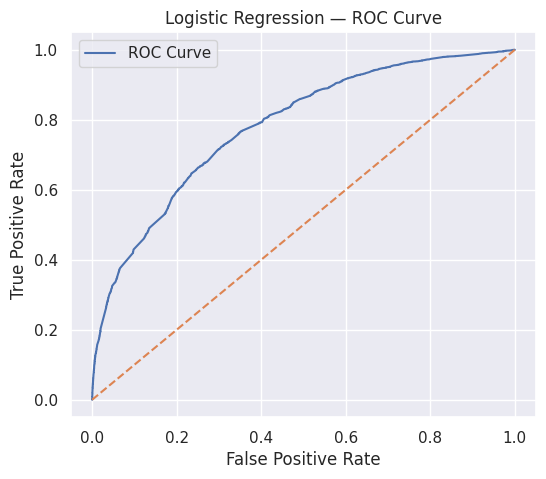

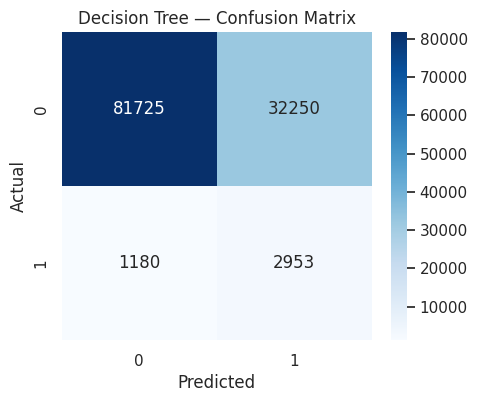

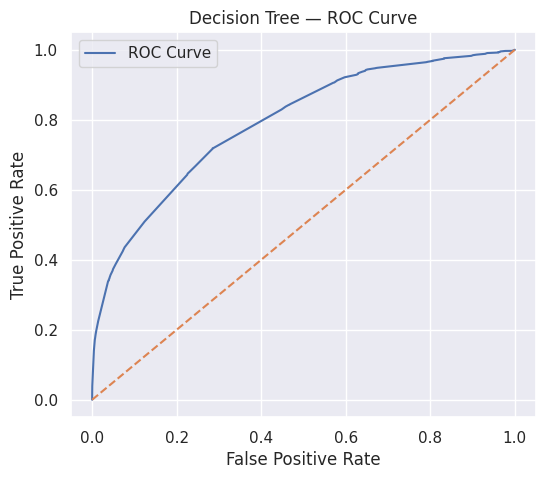

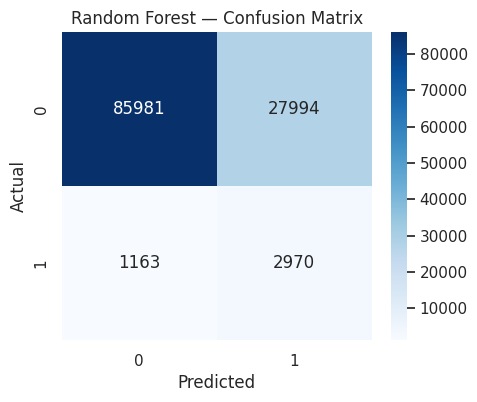

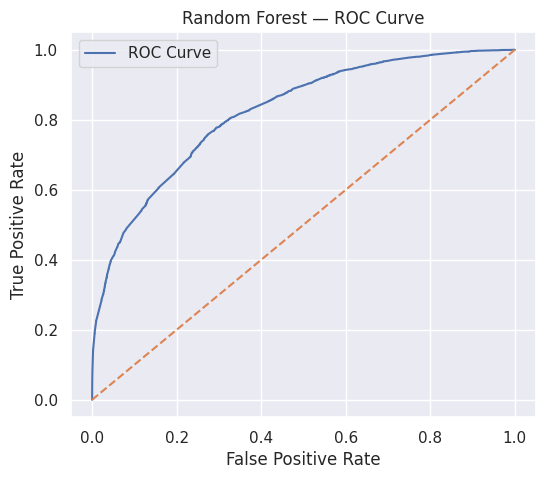

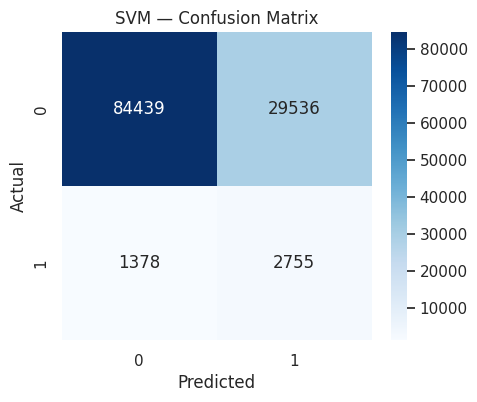

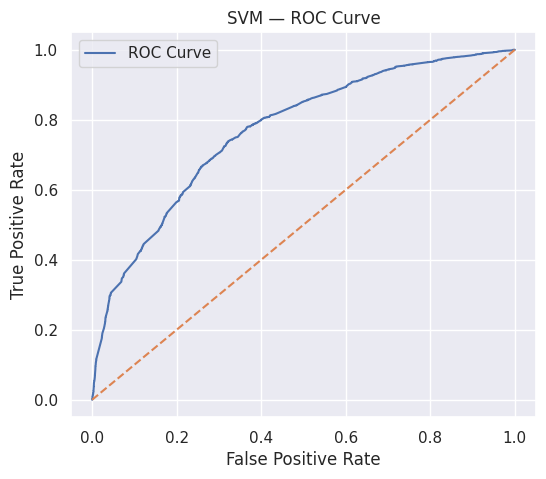

In [ ]:
import os

# Create output folder
os.makedirs("/kaggle/working/figures", exist_ok=True)

def save_current_fig(name):
    plt.savefig(f"/kaggle/working/figures/{name}.png", dpi=200, bbox_inches="tight")

# ---------- EDA PLOTS ----------

# Class distribution
plt.figure(figsize=(6,5))
sns.countplot(x="isFraud", data=df)
plt.title("Fraud Class Distribution (0 = Legit, 1 = Fraud)")
save_current_fig("01_class_distribution")
plt.show()

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(X_raw["TransactionAmt"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
save_current_fig("02_histogram_transaction_amt")
plt.show()

# Boxplot
plt.figure(figsize=(10,4))
sns.boxplot(x=X_raw["TransactionAmt"])
plt.title("Transaction Amount Boxplot")
save_current_fig("03_boxplot_transaction_amt")
plt.show()

# Correlation heatmap
top_corr = X_raw.corr(numeric_only=True)["TransactionAmt"].abs().sort_values(ascending=False).head(20).index
plt.figure(figsize=(14,10))
sns.heatmap(X_raw[top_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
save_current_fig("04_correlation_heatmap")
plt.show()

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_raw["TransactionDT"], y=X_raw["TransactionAmt"], hue=y, alpha=0.5)
plt.title("Transaction Amount vs Transaction Time")
save_current_fig("05_scatter_amt_vs_time")
plt.show()

# Pair plot
pair_columns = ["TransactionAmt", "dist1", "C1", "C2"]
pair_df = X_raw[pair_columns].copy()
pair_df["isFraud"] = y.values
g = sns.pairplot(pair_df.sample(min(3000, len(pair_df)), random_state=42), hue="isFraud", diag_kind="hist")
g.savefig("/kaggle/working/figures/06_pairplot.png", dpi=200, bbox_inches="tight")
plt.show()


# ---------- ORIGINAL (UNTUNED) MODEL CONFUSION MATRICES + ROC CURVES ----------

def evaluate_and_save(model, X_eval, y_eval, name, file_prefix):
    pred = model.predict(X_eval)
    prob = model.predict_proba(X_eval)[:, 1]

    cm = confusion_matrix(y_eval, pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} — Confusion Matrix")
    save_current_fig(f"{file_prefix}_confusion_matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y_eval, prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0,1], [0,1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} — ROC Curve")
    plt.legend()
    save_current_fig(f"{file_prefix}_roc_curve")
    plt.show()

models_to_plot = [
    (lr, "Logistic Regression", "07_lr"),
    (dt, "Decision Tree", "08_dt"),
    (rf, "Random Forest", "09_rf"),
    (svm, "SVM", "10_svm"),
    (knn, "KNN", "11_knn"),
    (nb, "Naive Bayes", "12_nb"),
    (xgb, "XGBoost", "13_xgb"),
]

for model, name, prefix in models_to_plot:
    evaluate_and_save(model, X_valid_selected, y_valid, name, prefix)


# ---------- ABLATION PLOT ----------
if "ablation_df" in dir():
    plt.figure(figsize=(8,5))
    plt.plot(ablation_df["K (Feature Count)"], ablation_df["ROC AUC"], marker='o', label="ROC AUC")
    plt.plot(ablation_df["K (Feature Count)"], ablation_df["F1 Score"], marker='s', label="F1 Score")
    plt.plot(ablation_df["K (Feature Count)"], ablation_df["Recall"], marker='^', label="Recall")
    plt.xlabel("Number of Selected Features (K)")
    plt.ylabel("Score")
    plt.title("Ablation Study: Random Forest Performance vs. Feature Count")
    plt.legend()
    plt.grid(True)
    save_current_fig("14_ablation_study")
    plt.show()


# ---------- NEW: TUNED MODEL CONFUSION MATRICES + ROC CURVES (THRESHOLD-CORRECTED) ----------
if "rf_best" in dir():
    tuned_models_to_plot = [
        (rf_best, "Random Forest (Tuned)", "15_rf_tuned"),
        (xgb_best, "XGBoost (Tuned)", "16_xgb_tuned"),
        (lr_best, "Logistic Regression (Tuned)", "17_lr_tuned"),
    ]
    for model, name, prefix in tuned_models_to_plot:
        evaluate_and_save(model, X_valid_selected, y_valid, name, prefix)


# ---------- NEW: THRESHOLD-TUNED CONFUSION MATRICES (the ones that fix sir's complaint) ----------
if "rf_best" in dir():
    from sklearn.metrics import precision_recall_curve

    def find_best_threshold(model, X, y):
        probs = model.predict_proba(X)[:, 1]
        precisions, recalls, thresholds = precision_recall_curve(y, probs)
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
        best_idx = f1_scores.argmax()
        best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
        return best_threshold

    threshold_models = [
        (rf_best, "Random Forest", "18_rf_threshold_tuned"),
        (xgb_best, "XGBoost", "19_xgb_threshold_tuned"),
        (lr_best, "Logistic Regression", "20_lr_threshold_tuned"),
    ]

    for model, name, prefix in threshold_models:
        thresh = find_best_threshold(model, X_valid_selected, y_valid)
        probs = model.predict_proba(X_valid_selected)[:, 1]
        new_preds = (probs >= thresh).astype(int)

        cm = confusion_matrix(y_valid, new_preds)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{name} — Confusion Matrix (Threshold={thresh:.2f})")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        save_current_fig(prefix)
        plt.show()


# ---------- NEW: ENSEMBLE CONFUSION MATRIX + ROC CURVE ----------
if "ensemble" in dir():
    evaluate_and_save(ensemble, X_valid_selected, y_valid, "Voting Ensemble", "21_ensemble")


# ---------- NEW: LEARNING CURVE (already saved during Step 4, re-save here if needed) ----------
if "train_sizes" in dir():
    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training Score")
    plt.plot(train_sizes, valid_scores.mean(axis=1), 's-', label="Cross-Validation Score")
    plt.xlabel("Training Set Size")
    plt.ylabel("ROC-AUC")
    plt.title("Learning Curve — Random Forest")
    plt.legend()
    plt.grid(True)
    save_current_fig("22_learning_curve_rf")
    plt.show()


# ---------- NEW: LOG-LOSS CURVE (already saved during Step 5, re-save here if needed) ----------
if "xgb_logloss" in dir():
    results = xgb_logloss.evals_result()
    plt.figure(figsize=(8,5))
    plt.plot(results['validation_0']['logloss'], label='Train')
    plt.plot(results['validation_1']['logloss'], label='Validation')
    plt.xlabel("Boosting Round")
    plt.ylabel("Log Loss")
    plt.title("XGBoost — Log-Loss Curve")
    plt.legend()
    plt.grid(True)
    save_current_fig("23_xgboost_logloss_curve")
    plt.show()


print("\nAll figures saved to /kaggle/working/figures/")
print(os.listdir("/kaggle/working/figures"))